## Odds ratio analysis of gene loss and gain

Testing whether the odds that genes in an orthogroup are missing, in single copy, or in multiple copies differs significantly between orb-weavers and non-orb-weavers

#### import modules

In [1]:
import os
import sys
import pandas as pd
from importlib import reload


# Set the working directory to the scripts directory
# This is necessary to ensure that the script can find the src directory
# and any other relative paths correctly.
scripts = os.path.abspath('')

# Ensure the src directory is in the Python path
src_path = os.path.abspath(os.path.join(scripts, '..', 'src'))
if src_path not in sys.path:
    sys.path.append(src_path)

# Define path data directorie
data = os.path.join(scripts, "..", "data")

# Import the odds_ratio_test function from the src module
import src.odds_ratio_test as ort
reload(ort)

/Users/calvin/anaconda3/envs/orb-selection/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<module 'src.odds_ratio_test' from '/Users/calvin/orb-selection/src/odds_ratio_test.py'>

In [2]:
%load_ext autoreload
%autoreload 2

#### specify input files

In [3]:
genecount_csv = f"{data}/N5.GeneCount.csv"
orb_list_filename = f"{data}/orbweavers-list.txt"
hog_node_genes_tsv = f"{data}/N5.tsv"


Testing for loss of genes first, using occupancy threshold of 75 (same as HyPhy analysis) 

In [9]:
results_dir = f"{data}/loss-test"

In [ ]:
from importlib import reload
reload(ort)

bootstrap_nomax = ort.odds_ratio_test(
    genecount_csv,
    orb_list_filename,
    hog_node_genes_tsv,
    "loss",
    occupancy_threshold=75
)

Number of columns before dropping empty columns: 103
98 spiders total, 44 orb-weavers, 54 non-orb-weavers
Launching bootstrapping test

** Minimum occupancy set to 75 **

Skew of LOR distribution: -0.2956901521341287
Standard deviation of LOR distribution: 1.2618789667271317
Mean of LOR distribution: -0.3058312386551137



100%|██████████| 10000/10000 [01:00<00:00, 165.86it/s]


Bootstrapping counter: 0
Probability that null is true: 0.00

Average bootstrapping mean: 0.06998955928584409
Average bootstrapping stddev: 0.7614784889552024
Average bootstrapping alpha=0.05: -1.1825310951176473

Filtering for occupancy >= 75, <= 98, and log odds ratio threshold 1.1825310951176473
No annotations saved, just returning filtered DataFrame and counts of hits.


Total significant hits: 1713, including U. diversus: 1445

Bootstrapping test with 10000 repetitions for loss (left-tailed)
 with 75 minimum occupancy and no maximum occupancy 


Orb-weaver list: /Users/calvin/orb-selection/scripts/../data/orbweavers-list.txt

Gene count file: /Users/calvin/orb-selection/scripts/../data/N5.GeneCount.csv

Hierarchical orthogroup file: /Users/calvin/orb-selection/scripts/../data/N5.tsv


Total number of HOGs in node: 107986
Total spiders: 98
Orb-weavers: 44
Non-orb-weavers: 54
True skew: -0.2956901521341287
True mean: -0.3058312386551137
True standard deviation: 1.2618789667271317




In [8]:
bootstrap_95 = ort.odds_ratio_test(
    genecount_csv,
    orb_list_filename,
    hog_node_genes_tsv,
    "loss",
    occupancy_threshold=75,
    max_occ=95
)

Number of columns before dropping empty columns: 103
98 spiders total, 44 orb-weavers, 54 non-orb-weavers
Launching bootstrapping test

** Maximum occupancy set to 95 **

** Minimum occupancy set to 75 **

Skew of LOR distribution: 0.14789325395694103
Standard deviation of LOR distribution: 1.5374700980875577
Mean of LOR distribution: -0.6300388762633876



100%|██████████| 10000/10000 [00:57<00:00, 174.58it/s]

Bootstrapping counter: 0
Probability that null is true: 0.00

Average bootstrapping mean: 0.0016845951406822155
Average bootstrapping stddev: 0.7386283845127142
Average bootstrapping alpha=0.05: -1.2132509820943629

Filtering for occupancy >= 75, <= 95, and log odds ratio threshold 1.2132509820943629
No annotations saved, just returning filtered DataFrame and counts of hits.


Total significant hits: 1188, including U. diversus: 949

Bootstrapping test with 10000 repetitions for loss (left-tailed)
 with 75 minimum occupancy and 95 maximum occupancy 


Orb-weaver list: /Users/calvin/orb-selection/scripts/../data/orbweavers-list.txt

Gene count file: /Users/calvin/orb-selection/scripts/../data/N5.GeneCount.csv

Hierarchical orthogroup file: /Users/calvin/orb-selection/scripts/../data/N5.tsv


Total number of HOGs in node: 107986
Total spiders: 98
Orb-weavers: 44
Non-orb-weavers: 54
True skew: 0.14789325395694103
True mean: -0.6300388762633876
True standard deviation: 1.5374700980875577



In [20]:
_, hits, uhits = bootstrap_95.get_hits_annots()

bootstrap_95.print_bootstrap_results(hits, uhits)

Filtering for occupancy >= 75, <= 95, and log odds ratio threshold 1.2132509820943629
No annotations saved, just returning filtered DataFrame and counts of hits.

Total significant hits: 1188, including U. diversus: 949

*********************** RESULTS ***********************

Bootstrapping test with 10000 repetitions for loss (left-tailed)
with 75 minimum occupancy and 95 maximum occupancy 

Orb-weaver list: /Users/calvin/orb-selection/scripts/../data/orbweavers-list.txt
Gene count file: /Users/calvin/orb-selection/scripts/../data/N5.GeneCount.csv
Hierarchical orthogroup file: /Users/calvin/orb-selection/scripts/../data/N5.tsv

Total number of HOGs in node: 107986
Total number of HOGs within occupancy threshold: 2627
Total spiders: 98
Orb-weavers: 44
Non-orb-weavers: 54
True skew: 0.14789325395694103
True mean: -0.6300388762633876
True standard deviation: 1.5374700980875577

Bootstrapped average skew: -0.05869642938479086
Bootstrapped average mean: 0.0016845951406822155
Bootstrapped a

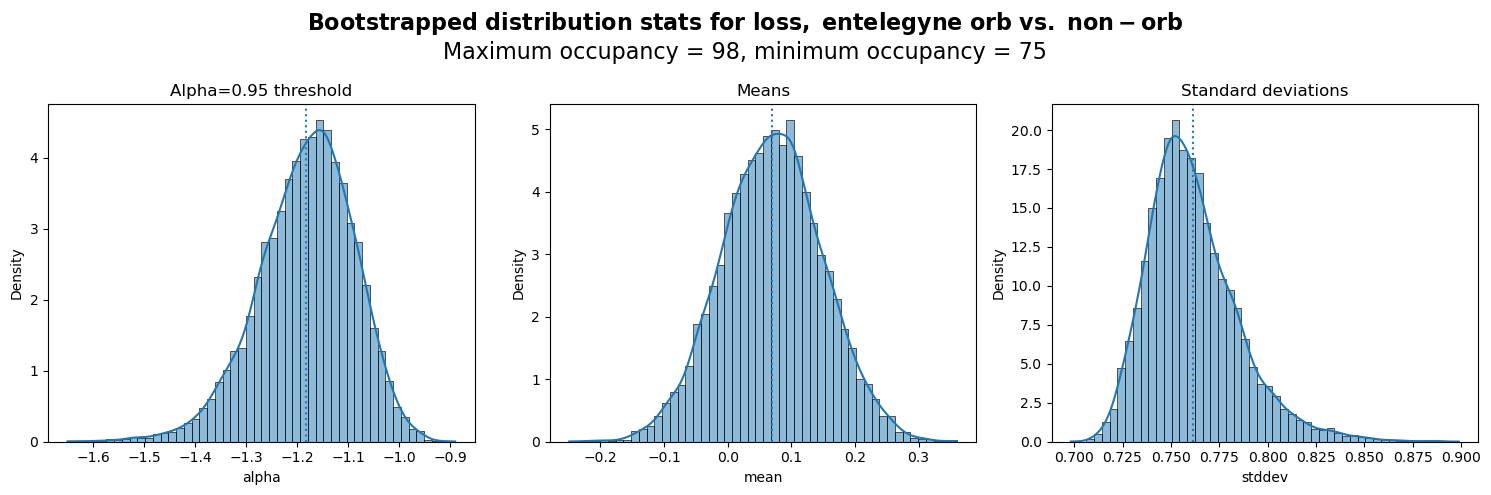

(<Figure size 1500x500 with 3 Axes>,
 array([<Axes: title={'center': 'Alpha=0.95 threshold'}, xlabel='alpha', ylabel='Density'>,
        <Axes: title={'center': 'Means'}, xlabel='mean', ylabel='Density'>,
        <Axes: title={'center': 'Standard deviations'}, xlabel='stddev', ylabel='Density'>],
       dtype=object))

In [21]:
text = "loss, entelegyne orb vs. non-orb".replace(" ", "\ ")
bootstrap_nomax.plot_bootstrap_stats(hist_txt=text)

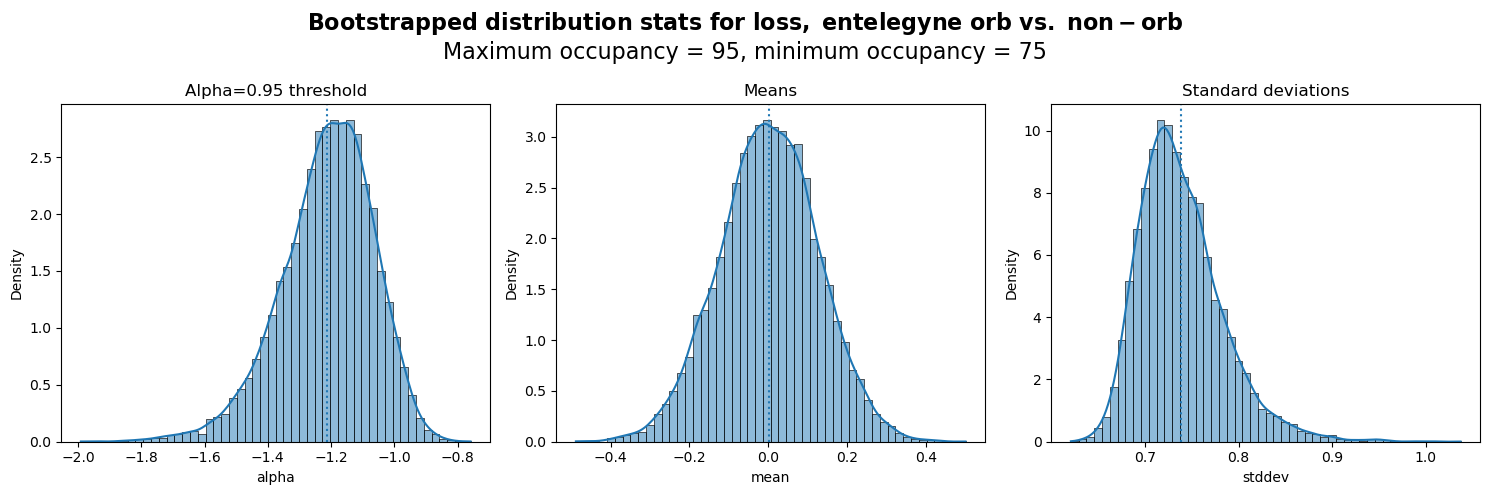

(<Figure size 1500x500 with 3 Axes>,
 array([<Axes: title={'center': 'Alpha=0.95 threshold'}, xlabel='alpha', ylabel='Density'>,
        <Axes: title={'center': 'Means'}, xlabel='mean', ylabel='Density'>,
        <Axes: title={'center': 'Standard deviations'}, xlabel='stddev', ylabel='Density'>],
       dtype=object))

In [22]:
bootstrap_95.plot_bootstrap_stats(hist_txt=text)

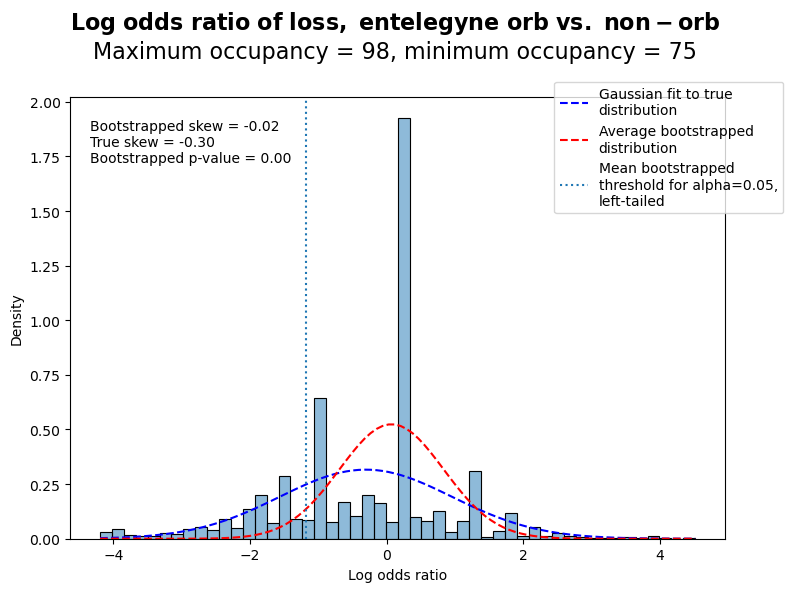

(<Figure size 800x600 with 1 Axes>,
 <Axes: xlabel='Log odds ratio', ylabel='Density'>)

In [23]:
bootstrap_nomax.plot_bootstrap_results(
    plot_name=text)

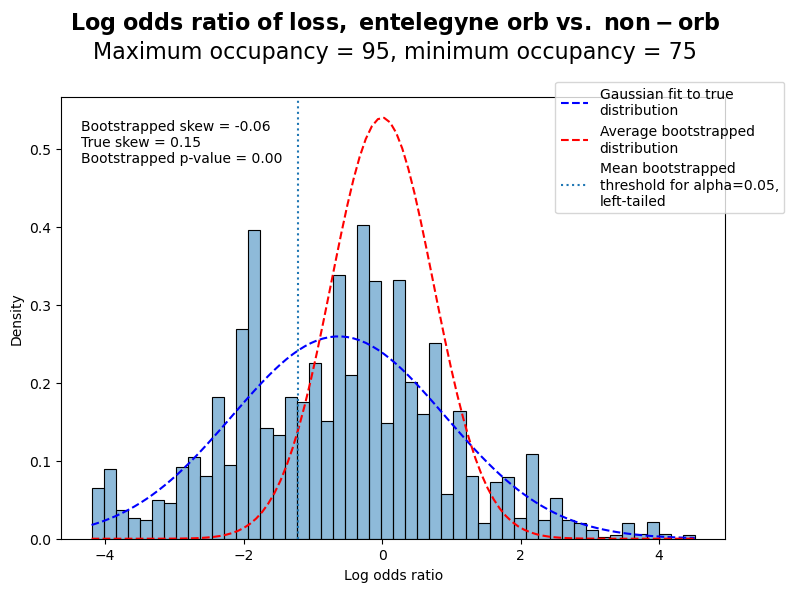

(<Figure size 800x600 with 1 Axes>,
 <Axes: xlabel='Log odds ratio', ylabel='Density'>)

In [24]:
bootstrap_95.plot_bootstrap_results(
    plot_name=text)

In [25]:
bootstrap_95_check = ort.odds_ratio_test(
    genecount_csv,
    orb_list_filename,
    hog_node_genes_tsv,
    "loss",
    occupancy_threshold=75,
    max_occ=95
)

Number of columns before dropping empty columns: 103
98 spiders total, 44 orb-weavers, 54 non-orb-weavers


LAUNCHING BOOTSTRAPPING TEST

** Maximum occupancy set to 95 **

** Minimum occupancy set to 75 **

Skew of LOR distribution: 0.14789325395694103
Standard deviation of LOR distribution: 1.5374700980875577
Mean of LOR distribution: -0.6300388762633876



100%|██████████| 10000/10000 [01:07<00:00, 149.18it/s]

Bootstrapping counter: 0
Probability that null is true: 0.00

Average bootstrapping mean: 0.003283858221223114
Average bootstrapping stddev: 0.7380910978773076
Average bootstrapping alpha=0.05: 1.2173356775853064

Filtering for occupancy >= 75, <= 95, and log odds ratio threshold 1.2173356775853064
No annotations saved, just returning filtered DataFrame and counts of hits.

Total significant hits: 1188, including U. diversus: 949

*********************** RESULTS ***********************

Bootstrapping test with 10000 repetitions for loss (left-tailed)
with 75 minimum occupancy and 95 maximum occupancy 

Orb-weaver list: /Users/calvin/orb-selection/scripts/../data/orbweavers-list.txt
Gene count file: /Users/calvin/orb-selection/scripts/../data/N5.GeneCount.csv
Hierarchical orthogroup file: /Users/calvin/orb-selection/scripts/../data/N5.tsv

Total number of HOGs in node: 107986
Total number of HOGs within occupancy threshold: 2627
Total spiders: 98
Orb-weavers: 44
Non-orb-weavers: 54
True

In [26]:
bootstrap_95_seed_144 = ort.odds_ratio_test(
    genecount_csv,
    orb_list_filename,
    hog_node_genes_tsv,
    "loss",
    occupancy_threshold=75,
    max_occ=95
)

Number of columns before dropping empty columns: 103
98 spiders total, 44 orb-weavers, 54 non-orb-weavers


LAUNCHING BOOTSTRAPPING TEST

** Maximum occupancy set to 95 **

** Minimum occupancy set to 75 **

Skew of LOR distribution: 0.14789325395694103
Standard deviation of LOR distribution: 1.5374700980875577
Mean of LOR distribution: -0.6300388762633876



100%|██████████| 10000/10000 [01:17<00:00, 129.62it/s]

Bootstrapping counter: 0
Probability that null is true: 0.00

Average bootstrapping mean: 0.0018998405449350785
Average bootstrapping stddev: 0.7383788936057143
Average bootstrapping alpha=0.05: 1.2164250417567093

Filtering for occupancy >= 75, <= 95, and log odds ratio threshold 1.2164250417567093
No annotations saved, just returning filtered DataFrame and counts of hits.

Total significant hits: 1188, including U. diversus: 949

*********************** RESULTS ***********************

Bootstrapping test with 10000 repetitions for loss (left-tailed)
with 75 minimum occupancy and 95 maximum occupancy 

Orb-weaver list: /Users/calvin/orb-selection/scripts/../data/orbweavers-list.txt
Gene count file: /Users/calvin/orb-selection/scripts/../data/N5.GeneCount.csv
Hierarchical orthogroup file: /Users/calvin/orb-selection/scripts/../data/N5.tsv

Total number of HOGs in node: 107986
Total number of HOGs within occupancy threshold: 2627
Total spiders: 98
Orb-weavers: 44
Non-orb-weavers: 54
Tru

In [27]:
bootstrap_95_seed_144_a_0_01 = ort.odds_ratio_test(
    genecount_csv,
    orb_list_filename,
    hog_node_genes_tsv,
    "loss",
    occupancy_threshold=75,
    max_occ=95, 
    alpha=0.01
)

Number of columns before dropping empty columns: 103
98 spiders total, 44 orb-weavers, 54 non-orb-weavers


LAUNCHING BOOTSTRAPPING TEST

** Maximum occupancy set to 95 **

** Minimum occupancy set to 75 **

Skew of LOR distribution: 0.14789325395694103
Standard deviation of LOR distribution: 1.5374700980875577
Mean of LOR distribution: -0.6300388762633876



100%|██████████| 10000/10000 [01:05<00:00, 151.95it/s]


Bootstrapping counter: 0
Probability that null is true: 0.00

Average bootstrapping mean: 0.002042610788099005
Average bootstrapping stddev: 0.738560885149953
Average bootstrapping alpha=0.05: 1.720192155806414

Filtering for occupancy >= 75, <= 95, and log odds ratio threshold 1.720192155806414
No annotations saved, just returning filtered DataFrame and counts of hits.

Total significant hits: 902, including U. diversus: 735

*********************** RESULTS ***********************

Bootstrapping test with 10000 repetitions for loss (left-tailed)
with 75 minimum occupancy and 95 maximum occupancy 

Orb-weaver list: /Users/calvin/orb-selection/scripts/../data/orbweavers-list.txt
Gene count file: /Users/calvin/orb-selection/scripts/../data/N5.GeneCount.csv
Hierarchical orthogroup file: /Users/calvin/orb-selection/scripts/../data/N5.tsv

Total number of HOGs in node: 107986
Total number of HOGs within occupancy threshold: 2627
Total spiders: 98
Orb-weavers: 44
Non-orb-weavers: 54
True ske

In [28]:
bootstrap_95_seed_144_a_0_01 = ort.odds_ratio_test(
    genecount_csv,
    orb_list_filename,
    hog_node_genes_tsv,
    "loss",
    occupancy_threshold=75,
    max_occ=95, 
    alpha=0.01,
    bootstrap_stat="skew"
)

Number of columns before dropping empty columns: 103
98 spiders total, 44 orb-weavers, 54 non-orb-weavers


LAUNCHING BOOTSTRAPPING TEST

** Maximum occupancy set to 95 **

** Minimum occupancy set to 75 **

Skew of LOR distribution: 0.14789325395694103
Standard deviation of LOR distribution: 1.5374700980875577
Mean of LOR distribution: -0.6300388762633876



100%|██████████| 10000/10000 [01:01<00:00, 163.60it/s]


Bootstrapping counter: 8594
Probability that null is true: 0.86

Average bootstrapping mean: 0.001875622140279361
Average bootstrapping stddev: 0.7384665833768486
Average bootstrapping alpha=0.05: 1.7198057884292146

Filtering for occupancy >= 75, <= 95, and log odds ratio threshold 1.7198057884292146
No annotations saved, just returning filtered DataFrame and counts of hits.

Total significant hits: 902, including U. diversus: 735

*********************** RESULTS ***********************

Bootstrapping test with 10000 repetitions for loss (left-tailed)
with 75 minimum occupancy and 95 maximum occupancy 

Orb-weaver list: /Users/calvin/orb-selection/scripts/../data/orbweavers-list.txt
Gene count file: /Users/calvin/orb-selection/scripts/../data/N5.GeneCount.csv
Hierarchical orthogroup file: /Users/calvin/orb-selection/scripts/../data/N5.tsv

Total number of HOGs in node: 107986
Total number of HOGs within occupancy threshold: 2627
Total spiders: 98
Orb-weavers: 44
Non-orb-weavers: 54
Tr

In [45]:
bootstrap_95_seed_144_a_0_01 = ort.odds_ratio_test(
    genecount_csv,
    orb_list_filename,
    hog_node_genes_tsv,
    "loss",
    occupancy_threshold=75,
    max_occ=95, 
    alpha=0.01,
    alternative="less"
)

98 spiders total, 44 orb-weavers, 54 non-orb-weavers

LAUNCHING BOOTSTRAPPING TEST

** Maximum occupancy set to 95 **

** Minimum occupancy set to 75 **

Counting bootstrapped distributions in which statistics
derived from randomly assigned test groups are SMALLER
than the true distribution's statistics (left-tailed)...



100%|██████████| 10000/10000 [00:56<00:00, 176.16it/s]


Bootstrapping counter for MEAN: 0
Bootstrapping counter for STD DEV: 10000
Bootstrapping counter for SKEW: 8534

Filtering log odds ratio results df for occupancy >= 75, <= 95
and log odds ratio threshold [-1.71573285  1.71964274]

*********************** RESULTS ***********************

Bootstrapping test with 10000 repetitions for loss (left-tailed)
with minimum occupancy *75* and maximum occupancy *95* 

Orb-weaver list: /Users/calvin/orb-selection/scripts/../data/orbweavers-list.txt
Gene count file: /Users/calvin/orb-selection/scripts/../data/N5.GeneCount.csv
Hierarchical orthogroup file: /Users/calvin/orb-selection/scripts/../data/N5.tsv

Total number of HOGs in node: 107986
Total number of HOGs within occupancy threshold: 2627
Total spiders: 98
Orb-weavers: 44
Non-orb-weavers: 54
True mean: -0.6300388762633876
True standard deviation: 1.5374700980875577
True skew: 0.14789325395694103

** BOOTSTRAPPING P-VALUES ** 

Probability that the null is true for MEAN: 0.0
Probability that

In [43]:
_, hits, uhits = bootstrap_95_seed_144_a_0_01.get_hits_annots()

bootstrap_95_seed_144_a_0_01.print_bootstrap_results(hits, uhits)

Filtering log odds ratio results df for occupancy >= 75, <= 95
and log odds ratio threshold [ 1.72256603 -1.71636993]

*********************** RESULTS ***********************

Bootstrapping test with 10000 repetitions for loss (right-tailed)
with minimum occupancy *75* and maximum occupancy *95* 

Orb-weaver list: /Users/calvin/orb-selection/scripts/../data/orbweavers-list.txt
Gene count file: /Users/calvin/orb-selection/scripts/../data/N5.GeneCount.csv
Hierarchical orthogroup file: /Users/calvin/orb-selection/scripts/../data/N5.tsv

Total number of HOGs in node: 107986
Total number of HOGs within occupancy threshold: 2627
Total spiders: 98
Orb-weavers: 44
Non-orb-weavers: 54
True mean: -0.6300388762633876
True standard deviation: 1.5374700980875577
True skew: 0.14789325395694103

** BOOTSTRAPPING P-VALUES ** 

Probability that the null is true for MEAN: 1.0
Probability that the null is true for STANDARD DEVIATION: 0.0
Probability that the null is true for SKEW: 0.138

Bootstrapped ave